# Análise de Dados com Jupyter

Este notebook demonstra as principais bibliotecas para análise de dados em Python.

## 1. Importando Bibliotecas Essenciais

In [2]:
print("Olá, mundo!")

Olá, mundo!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Trabalhando com NumPy

In [4]:
# Criar arrays NumPy
array_1d = np.array([1, 2, 3, 4, 5])
array_2d = np.random.rand(3, 4)

print('Array 1D:', array_1d)
print('\nArray 2D (3x4):')
print(array_2d)
print('\nEstatísticas - Média:', array_2d.mean(), 'Desvio Padrão:', array_2d.std())

Array 1D: [1 2 3 4 5]

Array 2D (3x4):
[[0.52283193 0.37618454 0.1781787  0.66394966]
 [0.13594853 0.31065255 0.27424113 0.83961097]
 [0.38623263 0.23093394 0.33040617 0.88481753]]

Estatísticas - Média: 0.42783235683301474 Desvio Padrão: 0.2381660397543257


## 3. Análise com Pandas

In [5]:
# Carregar dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

print('Primeiras linhas do dataset:')
print(df.head())
print('\nInformações do dataset:')
print(df.info())
print('\nEstatísticas descritivas:')
print(df.describe())

Primeiras linhas do dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species      

## 4. Visualização com Matplotlib

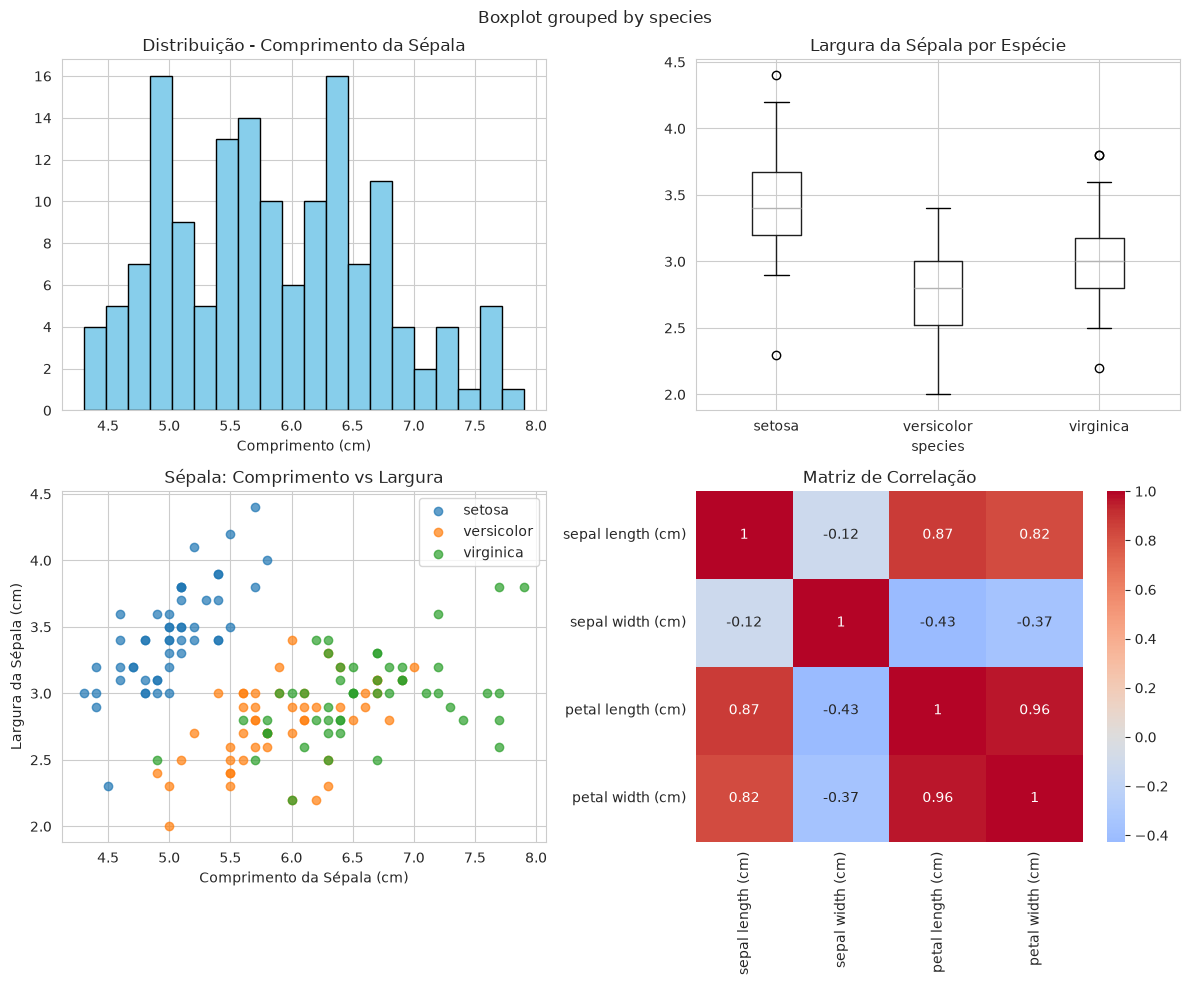

In [6]:
# Criar visualizações
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma
axes[0, 0].hist(df['sepal length (cm)'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribuição - Comprimento da Sépala')
axes[0, 0].set_xlabel('Comprimento (cm)')

# Box plot
df.boxplot(column='sepal width (cm)', by='species', ax=axes[0, 1])
axes[0, 1].set_title('Largura da Sépala por Espécie')

# Scatter plot
for species in iris.target_names:
    mask = df['species'] == species
    axes[1, 0].scatter(df[mask]['sepal length (cm)'], 
                      df[mask]['sepal width (cm)'],
                      label=species, alpha=0.7)
axes[1, 0].set_xlabel('Comprimento da Sépala (cm)')
axes[1, 0].set_ylabel('Largura da Sépala (cm)')
axes[1, 0].set_title('Sépala: Comprimento vs Largura')
axes[1, 0].legend()

# Correlação
sns.heatmap(df.corr(numeric_only=True), annot=True, ax=axes[1, 1], cmap='coolwarm', center=0)
axes[1, 1].set_title('Matriz de Correlação')

plt.tight_layout()
plt.show()

## 5. Agrupamento e Filtragem

In [ ]:
# Agrupamento por espécie
print('Média de características por espécie:')
print(df.groupby('species').mean())

# Filtragem
setosa = df[df['species'] == 'setosa']
print(f'\nTotal de amostras Setosa: {len(setosa)}')
print(f'Comprimento médio da sépala em Setosa: {setosa["sepal length (cm)"].mean():.2f} cm')

## 6. Machine Learning Básico

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Preparar dados
X = df.drop('species', axis=1)
y = df['species']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Avaliação
y_pred = modelo.predict(X_test)
acurácia = accuracy_score(y_test, y_pred)

print(f'Acurácia do modelo: {acurácia:.2%}')
print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred))

# Importância das features
print('\nImportância das Features:')
for feature, importance in zip(iris.feature_names, modelo.feature_importances_):
    print(f'{feature}: {importance:.4f}')